# ViT from scratch

ViTs (Vision transformers) are a purely attention based architecture developed by Google. They were originally trained and tested on Imagenet, however I have a Macbook so I will be training and testing my custom model and an adapted pretrained model. 

In [56]:
import torch
import torchvision
import torch.nn as nn

import torchinfo
from torchinfo import summary

import matplotlib
import matplotlib.pyplot as plt

print(f"Torch version : {torch.__version__}")
print(f"Torchvision version : {torchvision.__version__}")
print(f"Torchinfo version : {torchinfo.__version__}")
print(f"Matplotlib version : {matplotlib.__version__}")


Torch version : 2.8.0
Torchvision version : 0.24.0
Torchinfo version : 1.8.0
Matplotlib version : 3.10.8


## Getting the data ready

First, we'll download the data and extract the class names

In [154]:
train_data = torchvision.datasets.CIFAR10(
    root="data",
    train=True,
    transform=torchvision.transforms.ToTensor(),
    download=True
)

test_data = torchvision.datasets.CIFAR10(
    root="data",
    train=False,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None,
    download=True
)

In [155]:
class_names = train_data.classes
class_to_idx = train_data.class_to_idx
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}

matplotlib.pyplot expects data to be in a HWC (height–width–channels) format, however pytorch provides the images in a (channels–height–width) therefore to visualise it, the data has to be manipulated

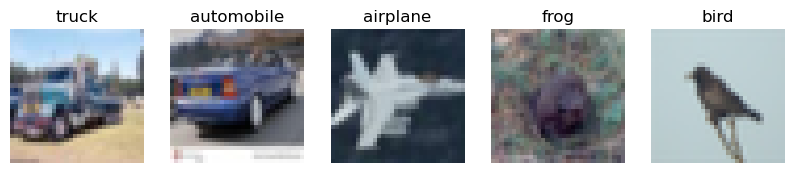

In [156]:
fig = plt.figure(figsize=(10,10))
row , col = 1,5
for i in range (1,(row * col) + 1):
    id = torch.randint(size=[1],low = 0 , high=len(train_data)).item()
    img , label = train_data[id]
    fig.add_subplot(row , col , i)
    plt.imshow(img.permute(1,2,0))
    plt.title(class_names[label])
    plt.axis(False)

In [157]:
COLOUR_CHANNELS,HEIGHT,WIDTH = train_data[0][0].shape[0],train_data[0][0].shape[1],train_data[0][0].shape[2]
COLOUR_CHANNELS,HEIGHT,WIDTH

(3, 32, 32)

Patches are small fixed sections of a split up image so transformers can relate each section to each other to learn the image better and not require reccurence. The number of patches is decided by the original image size and the patch size. The patch size in this is denoted by $P$.

In [158]:
PATCH_SIZE = 8
num_patches_per_row = int(HEIGHT/PATCH_SIZE)
num_patches_per_col = int(WIDTH/PATCH_SIZE)
num_patches = int((HEIGHT * WIDTH) / PATCH_SIZE**2)
PATCH_SIZE, num_patches_per_row,num_patches_per_col,num_patches

(8, 4, 4, 16)

The model first has to embed the image into tensors that are able to be processed. The layer which does this is called the embedding layer.
The image tensor originally has the shape $\mathbf{x} \in \mathbb{R}^{H \times W \times C}$, and it is transformed into a sequence of flattened 2D patches of shape $\mathbf{x}_p \in \mathbb{R}^{N \times (P^{2} \cdot C)}$, where $C$ is the number of colour channels and $H$ and $W$ correspond to height and width.
The resolution of each patch is $(P,P)$, where $P$ is the size of a patch. 

In [159]:
embedding_layer_input_shape = (HEIGHT, WIDTH, COLOUR_CHANNELS)
embedding_layer_output_shape = (num_of_patches, PATCH_SIZE**2 * COLOUR_CHANNELS)

print(f"Input shape (single 2D image): {embedding_layer_input_shape}")
print(f"Output shape (single 2D image flattened into patches): {embedding_layer_output_shape}")

Input shape (single 2D image): (32, 32, 3)
Output shape (single 2D image flattened into patches): (64, 192)


In [160]:
test_img, test_label = train_data[0]

Number of patches per row: 4        
Number of patches per column: 4        
Total patches: 16        
Patch size: 8 pixels x 8 pixels


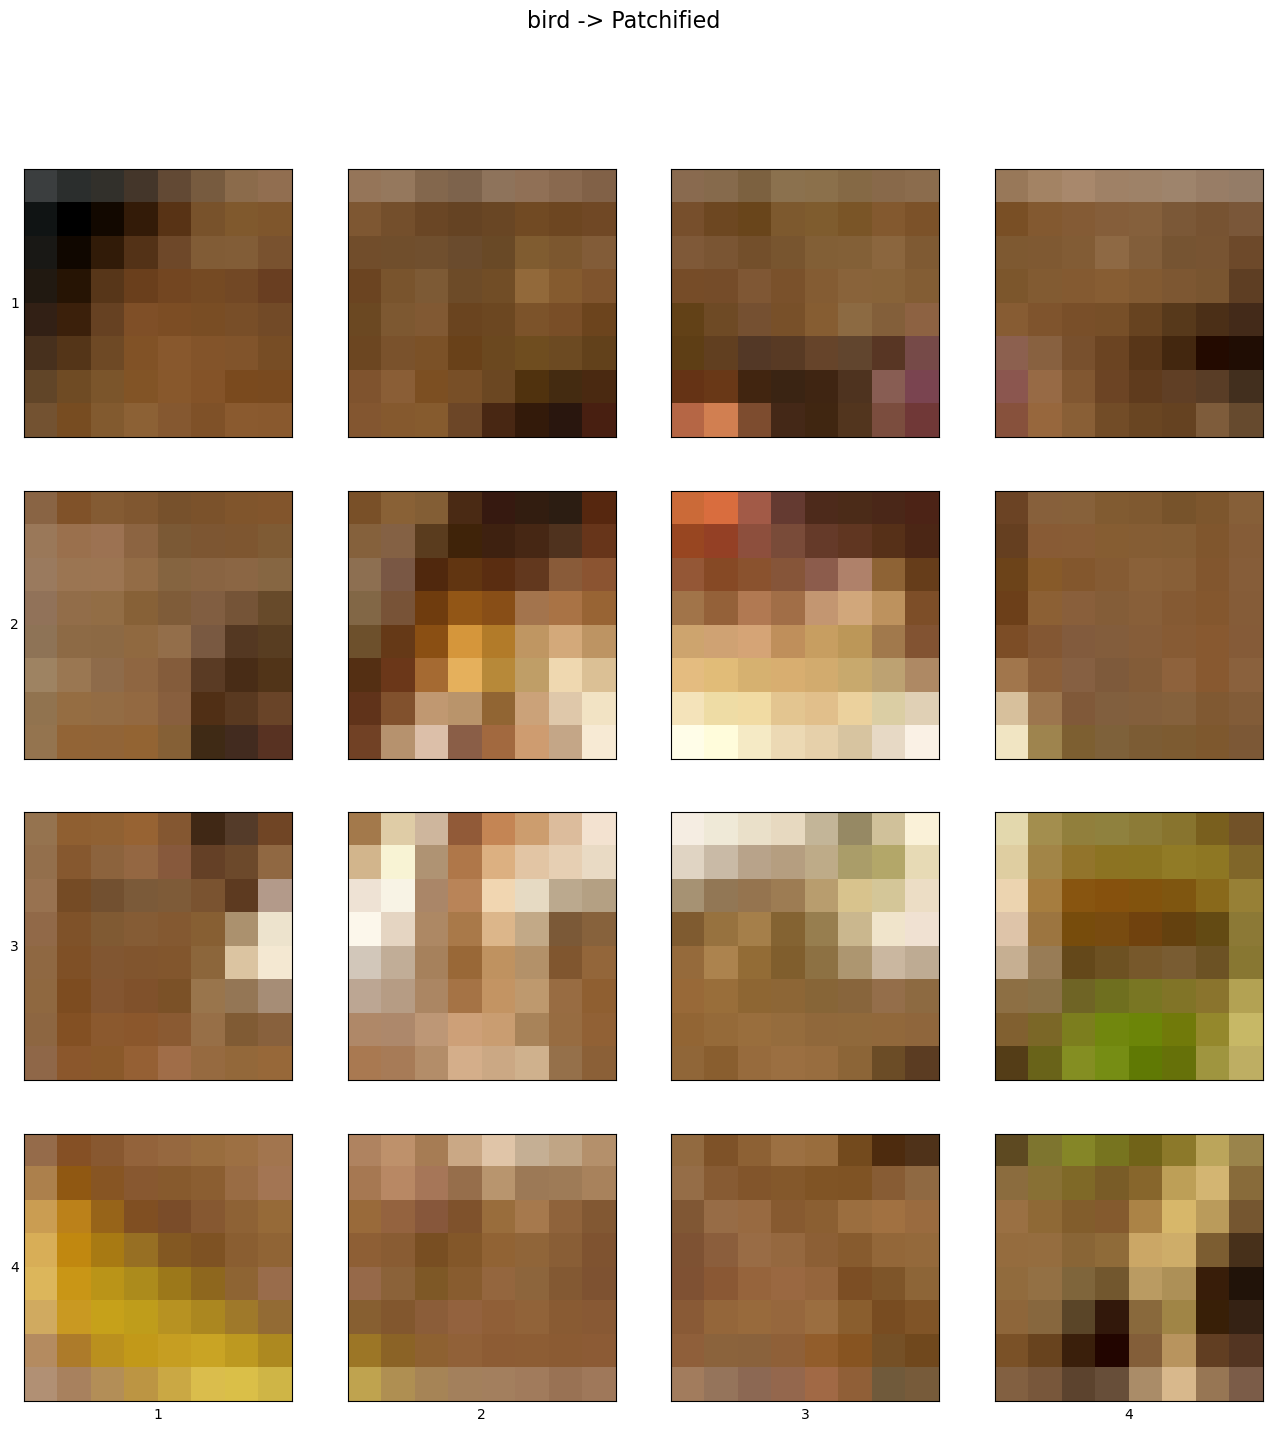

In [161]:
test_image_permuted = test_img.permute(1, 2, 0)

img_size = HEIGHT  # Assuming square images, so HEIGHT == WIDTH
assert img_size % PATCH_SIZE == 0, "Image size must be divisible by patch size"
print(f"Number of patches per row: {num_patches_per_row}\
        \nNumber of patches per column: {num_patches_per_col}\
        \nTotal patches: {num_patches}\
        \nPatch size: {PATCH_SIZE} pixels x {PATCH_SIZE} pixels")

# Create a series of subplots
fig, axs = plt.subplots(nrows=img_size // PATCH_SIZE, # need int not float
                        ncols=img_size // PATCH_SIZE,
                        figsize=(num_patches, num_patches),
                        sharex=True,
                        sharey=True)

# Loop through height and width of image
for i, patch_height in enumerate(range(0, img_size, PATCH_SIZE)): # iterate through height
    for j, patch_width in enumerate(range(0, img_size, PATCH_SIZE)): # iterate through width

        # Plot the permuted image patch (image_permuted -> (Height, Width, Color Channels))
        axs[i, j].imshow(test_image_permuted[patch_height:patch_height+PATCH_SIZE, # iterate through height
                                        patch_width:patch_width+PATCH_SIZE, # iterate through width
                                        :]) # get all color channels

        # Set up label information, remove the ticks for clarity and set labels to outside
        axs[i, j].set_ylabel(i+1,
                             rotation="horizontal",
                             horizontalalignment="right",
                             verticalalignment="center")
        axs[i, j].set_xlabel(j+1)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        axs[i, j].label_outer()

# Set a super title
fig.suptitle(f"{class_names[label]} -> Patchified", fontsize=16)
plt.show()

Patches can be created using a Conv2D layer with a kernel size and stride equal to the patch size. 
It has an input of 3 due to the amount of colour channels and has an out channel of $P^2 \times C$ as thats the dimension of one patch.

In [162]:
conv2d = torch.nn.Conv2d(
    in_channels= 3,
    out_channels= PATCH_SIZE**2 * COLOUR_CHANNELS, 
    kernel_size=PATCH_SIZE,
    padding=0,
    stride=PATCH_SIZE
) #Creating patches using Conv2D layer
conv2d

Conv2d(3, 192, kernel_size=(8, 8), stride=(8, 8))

In [163]:
test_image,label = train_data[0]
img_out_of_conv = conv2d(test_image.unsqueeze(0))
img_out_of_conv.shape

torch.Size([1, 192, 4, 4])

192 is the flattened 2D projection of each patch. There are 4 rows and 4 columns of flattened patches therefore the shape (4,4). Then each patch is flattened into 8 by 8 pixels with 3 colour channels therefore 192 values.

(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

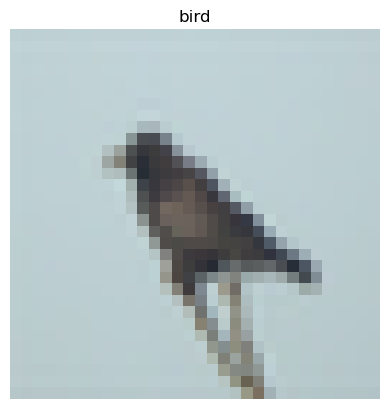

In [164]:
img , label = train_data[id]
fig.add_subplot(row , col , i)
plt.imshow(img.permute(1,2,0))
plt.title(class_names[label])
plt.axis(False)

If we had more compute power and I was running then on larger images you could start to slighlty see resemblences to the images.

Showing random convolutional feature maps from indexes: [46, 45, 5, 31, 9]


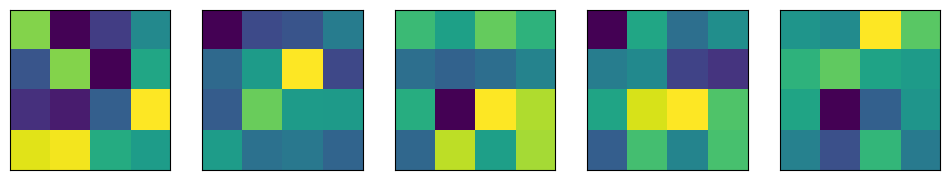

In [165]:
# Plot random 5 convolutional feature maps
import random
random_indexes = random.sample(range(0, 48), k=5) # pick 5 numbers between 0 and the embedding size
print(f"Showing random convolutional feature maps from indexes: {random_indexes}")

# Create plot
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(12, 12))

# Plot random image feature maps
for i, idx in enumerate(random_indexes):
    image_conv_feature_map = img_out_of_conv[:, idx, :, :] # index on the output tensor of the convolutional layer
    axs[i].imshow(image_conv_feature_map.squeeze().detach().numpy())
    axs[i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[]);

Now we will make a class that does the patch embedding for us.

In [166]:
class PatchEmbedding(nn.Module):
    def __init__(self,
                in_channels = COLOUR_CHANNELS,
                patch_size = PATCH_SIZE,
                embedding_dimension = PATCH_SIZE**2 * COLOUR_CHANNELS
):
        super().__init__()
        self.patcher = nn.Conv2d(
                                in_channels= in_channels,
                                out_channels= embedding_dimension,
                                kernel_size=patch_size,
                                padding=0,
                                stride=patch_size
        )
        self.flatten = nn.Flatten(
            start_dim=2,
            end_dim=3
        )

        self.patch_size=patch_size

    def forward(self,x:torch.Tensor) -> torch.Tensor:
        assert x.shape[-1] % self.patch_size == 0

        patched_x = self.patcher(x)
        flattened_x = self.flatten(patched_x)
        return flattened_x.permute(0,2,1)
    

patchify = PatchEmbedding()

print(f"Input image shape: {img.unsqueeze(0).shape}")
patch_embedded_image = patchify(img.unsqueeze(0)) # add an extra batch dimension on the 0th index, otherwise will error
print(f"Output patch embedding shape: {patch_embedded_image.shape}")


Input image shape: torch.Size([1, 3, 32, 32])
Output patch embedding shape: torch.Size([1, 16, 192])


In [167]:
summary(
    model=PatchEmbedding(),
    input_size=test_image.unsqueeze(0).shape,
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
    row_settings=["var_names"]
)

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
PatchEmbedding (PatchEmbedding)          [1, 3, 32, 32]       [1, 16, 192]         --                   True
├─Conv2d (patcher)                       [1, 3, 32, 32]       [1, 192, 4, 4]       37,056               True
├─Flatten (flatten)                      [1, 192, 4, 4]       [1, 192, 16]         --                   --
Total params: 37,056
Trainable params: 37,056
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.59
Input size (MB): 0.01
Forward/backward pass size (MB): 0.02
Params size (MB): 0.15
Estimated Total Size (MB): 0.19

In [168]:
print(f"PATCH_SIZE: {PATCH_SIZE}")
print(f"HEIGHT: {HEIGHT}")
print(f"WIDTH: {WIDTH}")
print(f"IMAGE SHAPE: {test_image.shape}")

PATCH_SIZE: 8
HEIGHT: 32
WIDTH: 32
IMAGE SHAPE: torch.Size([3, 32, 32])


The following code will be a formalisation of recreating the first equation in the paper.
$$
\mathbf{z}_0=\left[\mathbf{x}_{\text {class }} ; \mathbf{x}_p^1 \mathbf{E} ; \mathbf{x}_p^2 \mathbf{E} ; \cdots ; \mathbf{x}_p^N \mathbf{E}\right]+\mathbf{E}_{\text {pos }}, \quad \mathbf{E} \in \mathbb{R}^{\left(P^2 \cdot C\right) \times D}, \mathbf{E}_{\text {pos }} \in \mathbb{R}^{(N+1) \times D}
$$

In [169]:
PATCH_SIZE, HEIGHT, WIDTH

(8, 32, 32)

This section formalises and completes the following math equation sections from Equation 1.

$[\mathbf{x}_p^1 \mathbf{E} ; \mathbf{x}_p^2 \mathbf{E} ; \cdots ; \mathbf{x}_p^N \mathbf{E}] ;  \quad \mathbf{E} \in \mathbb{R}^{\left(P^2 \cdot C\right) \times D}$

In [176]:
print(f"Image tensor shape : {test_image.shape}")

test_image_with_batch_dim = test_image.unsqueeze(0)
print(f"Image tensor shape with batch dimension: {test_image_with_batch_dim.shape}")
batch_size = test_image_with_batch_dim.shape[0]

patch_embedding_layer = PatchEmbedding(
    in_channels=3, #RGB channels
    patch_size=PATCH_SIZE,
    embedding_dimension=PATCH_SIZE**2 * COLOUR_CHANNELS #As stated in the paper D = P^2 * C
)
patch_embedding = patch_embedding_layer(test_image_with_batch_dim)

f"Patch embedding shape: {patch_embedding.shape}"

Image tensor shape : torch.Size([3, 32, 32])
Image tensor shape with batch dimension: torch.Size([1, 3, 32, 32])


'Patch embedding shape: torch.Size([1, 16, 192])'

This creates the class token by creating a trainable tensor of 1s to attach to the patch embedding.
$\mathbf{x}_{\text {class }}$

In [ ]:
batch_size = patch_embedding.shape[0]
embedding_dimension = patch_embedding.shape[2]
number_of_patches = patch_embedding.shape[1]

class_token = nn.Parameter(
    torch.ones(batch_size,1,embedding_dimension),
    requires_grad=True #Trainable parameter
)
print(f"Class token shape: {class_token.shape}")

patch_embedding_concat_class_token = torch.cat((class_token,patch_embedding), dim=1)
print(f"Patch embedding with class token shape: {patch_embedding_concat_class_token.shape}")

Class token shape: torch.Size([1, 1, 192])
Patch embedding with class token shape: torch.Size([1, 17, 192])


This creates the position embedding through also creating a tensor of trainable 1s.
$\mathbf{E}_{\text {pos}},  \mathbf{E}_{\text {pos }} \in \mathbb{R}^{(N+1) \times D}$

In [ ]:
position_embedding = nn.Parameter(
    torch.ones(1,
               num_patches+1,
               embedding_dimension)
    ,requires_grad=True #Trainable parameter
)

patch_and_position_embedding = patch_embedding_concat_class_token + position_embedding
print(f"Position embedding shape: {position_embedding.shape}")
print(f"Patch embedding with position embedding shape: {patch_and_position_embedding.shape}")


Position embedding shape: torch.Size([1, 17, 192])
Patch embedding with position embedding shape: torch.Size([1, 17, 192])
